# Spectral and Wavelet Features

**Chapter 9 | Section 9.2**

**Docker image**: `ml4t`

Every method so far has described a series by what it does over time. A **spectral**
method describes it by what it is made of: a sum of oscillations at different
frequencies, each with its own strength. The question changes from "where is the level
going" to "how much of the movement happens on a weekly cycle, and how much on a
quarterly one", and some things that are invisible in a price chart are obvious in that
accounting.

**Learning objectives**

- Split a return series into components at different time scales, and read off which
  scales carry most of its variation.
- Say why the standard version of that split cannot be used as a feature, and translate
  what it shows into a rolling calculation that can.
- Compute the frequency content of a moving window and turn it into columns: how much
  total movement there is, at what period the strongest oscillation sits, how spread out
  the frequency content is, and what share sits in the slowest band.
- Estimate the same frequency content more stably by averaging over overlapping
  segments, and read the result as a picture of frequency against time.
- Recognise when a spectral quantity is a rescaling of something you already have.

**Book reference**

Chapter 9, Section 9.2 (Transforming signals to uncover hidden structure).

**Prerequisites**

`01_visual_diagnostics` for stationarity, which is what makes a spectrum meaningful:
the frequency content of a series whose properties change over time is an average over
periods that do not belong together.

## Setup

In [1]:
"""Spectral and Wavelet Features - frequency-domain feature engineering."""

import importlib
import logging
from datetime import datetime
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from ml4t.engineer.features.ml import fourier_features, rolling_entropy
from ml4t.engineer.logging import setup_logging
from scipy.signal import welch

from data import load_etfs
from utils.style import COLORS, FIGSIZE, show_with_alt

setup_logging(level=logging.ERROR)  # per-call timing notices, not results

pywt = cast(Any, importlib.import_module("pywt"))

# A sequential ramp for the one heatmap, built from palette entries so it runs light to
# dark in a single direction and survives a grayscale reduction.
SPECTRUM_CMAP = LinearSegmentedColormap.from_list(
    "ml4t_spectrum", [COLORS["bg_light"], COLORS["amber"], COLORS["copper"], COLORS["blue"]]
)

In [2]:
START_DATE = "2015-01-01"
END_DATE = "2024-12-31"

## The series

Ten years of SPY daily returns. Returns rather than prices, because a spectrum
decomposes a series into oscillations around a constant level and a price has no
constant level to oscillate around: its spectrum is dominated by the trend and says
nothing else.

In [3]:
etfs = load_etfs(symbols=["SPY"])
spy = etfs.select(["timestamp", "close"]).sort("timestamp")

START = datetime.strptime(START_DATE, "%Y-%m-%d")
END = datetime.strptime(END_DATE, "%Y-%m-%d")
spy = spy.filter((pl.col("timestamp") >= START) & (pl.col("timestamp") <= END))
spy = spy.with_columns(returns=pl.col("close").pct_change()).drop_nulls()

spy_pd = spy.to_pandas().set_index("timestamp")
returns = spy_pd["returns"].to_numpy(dtype=float, copy=True)
prices = spy_pd["close"].to_numpy(dtype=float, copy=True)
sessions = spy_pd.index

print(f"SPY: {len(spy_pd):,} sessions ({sessions.min().date()} to {sessions.max().date()})")

SPY: 2,515 sessions (2015-01-05 to 2024-12-31)


# Part 1: wavelets, and why they stay in the research notebook

A **wavelet decomposition** splits a series into components at doubling time scales. The
first detail component holds what changes fastest, the second holds what changes half as
fast, and so on; what is left at the end is the slowest movement of all. On daily data
with five levels the components cover roughly two to four sessions, four to eight,
eight to sixteen, sixteen to thirty-two, thirty-two to sixty-four, and everything slower.

The reason this is an analysis tool and not a feature is in how the components are built.
The discrete wavelet transform runs a filter both forward and backward over the whole
series, so the value of a component at any session depends on sessions after it. Every
component is therefore non-causal, and a model trained on one is reading its own future.
What the decomposition is for is deciding which scales are worth building causal features
at, which is what the second half of this part does.

## Three wavelet families

A **wavelet family** is the shape of the filter the transform runs. The three below
differ in length and in how symmetric they are, which trades localisation in time against
localisation in frequency: a longer filter separates frequencies more sharply and smears
a sudden event over more sessions.

In [4]:
WAVELET_FAMILIES = {"db6": "Daubechies-6", "sym6": "Symlet-6", "coif3": "Coiflet-3"}
DEFAULT_WAVELET = "db6"
DECOMPOSITION_LEVELS = 5

display(
    pd.DataFrame(
        [
            {
                "wavelet": name,
                "code": code,
                "filter length": pywt.Wavelet(code).dec_len,
                "vanishing moments": pywt.Wavelet(code).vanishing_moments_psi,
                "symmetry": pywt.Wavelet(code).symmetry,
            }
            for code, name in WAVELET_FAMILIES.items()
        ]
    )
)

,wavelet,code,filter length,vanishing moments,symmetry
0,Daubechies-6,db6,12,6,asymmetric
1,Symlet-6,sym6,12,6,near symmetric
2,Coiflet-3,coif3,18,6,near symmetric


In [5]:
def wavelet_decompose(signal: np.ndarray, wavelet: str, level: int) -> dict[str, np.ndarray]:
    """Split *signal* into one component per scale. Non-causal: reads the whole series."""
    coefficients = pywt.wavedec(signal, wavelet, level=level)

    components = {
        f"A{level}": pywt.upcoef("a", coefficients[0], wavelet, level=level, take=len(signal))
    }
    for i, detail in enumerate(coefficients[1:], 1):
        components[f"D{level - i + 1}"] = pywt.upcoef(
            "d", detail, wavelet, level=level - i + 1, take=len(signal)
        )
    return components


SCALE_LABELS = {
    "D1": "D1, 2 to 4 sessions",
    "D2": "D2, 4 to 8 sessions",
    "D3": "D3, 8 to 16 sessions",
    "D4": "D4, 16 to 32 sessions",
    "D5": "D5, 32 to 64 sessions",
    "A5": "A5, slower than 64 sessions",
}

decomposition = wavelet_decompose(returns, DEFAULT_WAVELET, DECOMPOSITION_LEVELS)

The panels below and the variance chart after them read fastest scale first, so the
scales are listed in that order explicitly. Sorting the component names alphabetically
would put the slowest one first, because `A` precedes `D`.

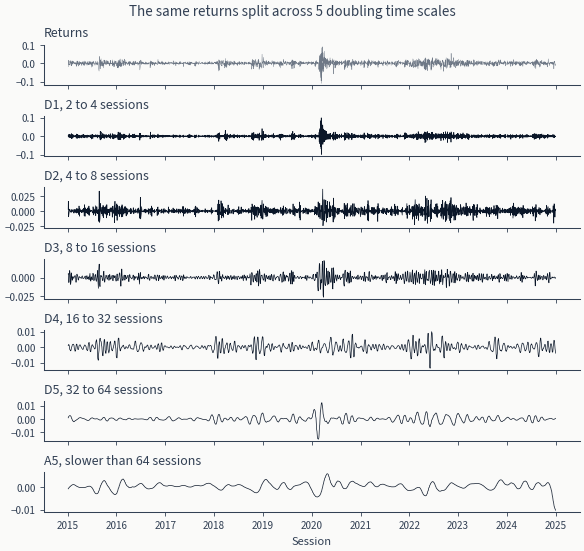

In [6]:
ordered_scales = [f"D{level}" for level in range(1, DECOMPOSITION_LEVELS + 1)] + [
    f"A{DECOMPOSITION_LEVELS}"
]
fig, axes = plt.subplots(len(ordered_scales) + 1, 1, figsize=FIGSIZE["grid_3x2"], sharex=True)

axes[0].plot(sessions, returns, linewidth=0.3, alpha=0.7, color=COLORS["neutral"])
axes[0].set_title("Returns")
for ax, name in zip(axes[1:], ordered_scales):
    ax.plot(sessions, decomposition[name], linewidth=0.5, color=COLORS["blue"])
    ax.set_title(SCALE_LABELS[name])
axes[-1].set_xlabel("Session")

fig.suptitle(f"The same returns split across {DECOMPOSITION_LEVELS} doubling time scales")
show_with_alt(
    fig,
    "Seven stacked panels sharing a time axis. The top is the SPY daily return series. "
    "Below it, one panel per scale from the fastest to the slowest: the fast panels look "
    "like the return series itself and carry most of its amplitude, and each successive "
    "panel is smoother and smaller, with the slowest panel a gentle wave close to zero. "
    "Every panel widens sharply in early 2020.",
)

## Which scales carry the movement

The components add back to the original series, so their variances say how the total
variation of returns is distributed across time scales. This is the number the
decomposition exists to produce.

In [7]:
scale_variance = pd.DataFrame(
    [
        {
            "scale": SCALE_LABELS[name],
            "share of return variance, percent": 100
            * np.var(decomposition[name])
            / np.var(returns),
        }
        for name in ordered_scales
    ]
)
display(scale_variance)

,scale,"share of return variance, percent"
0,"D1, 2 to 4 sessions",57.467560
1,"D2, 4 to 8 sessions",20.621724
2,"D3, 8 to 16 sessions",11.861042
3,"D4, 16 to 32 sessions",4.638387
4,"D5, 32 to 64 sessions",3.493956
5,"A5, slower than 64 sessions",2.215203


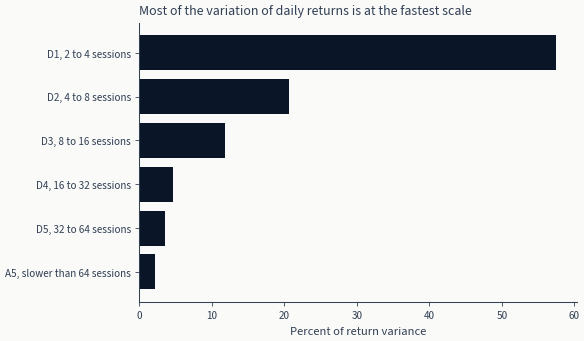

In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.barh(
    scale_variance["scale"],
    scale_variance["share of return variance, percent"],
    color=COLORS["blue"],
)
ax.invert_yaxis()
ax.set_xlabel("Percent of return variance")
ax.set_title("Most of the variation of daily returns is at the fastest scale")
show_with_alt(
    fig,
    "A horizontal bar chart of six wavelet scales ordered from fastest at the top to "
    "slowest at the bottom. The fastest scale's bar is much the longest and each "
    "successive bar is shorter, with the slowest two barely visible.",
)

## Do the families disagree

The choice of family is the first thing anyone asks about and the least consequential
decision here. Comparing the slowest and the fastest component under all three shows
where the choice can and cannot matter.

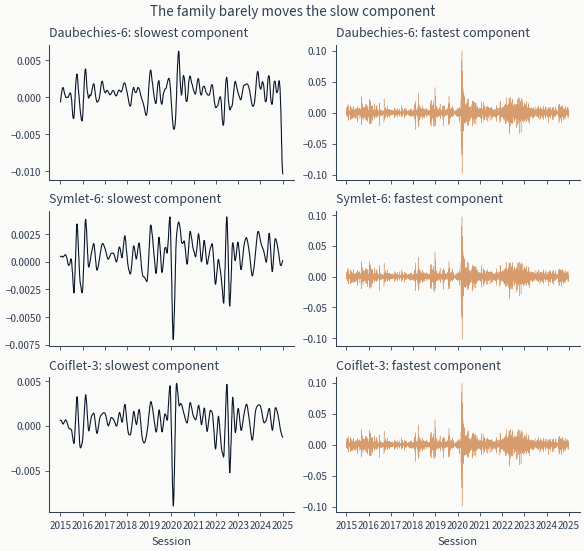

In [9]:
fig, axes = plt.subplots(len(WAVELET_FAMILIES), 2, figsize=FIGSIZE["grid_3x2"], sharex=True)

for row, (code, name) in enumerate(WAVELET_FAMILIES.items()):
    components = wavelet_decompose(returns, code, DECOMPOSITION_LEVELS)
    axes[row, 0].plot(
        sessions, components[f"A{DECOMPOSITION_LEVELS}"], linewidth=0.8, color=COLORS["blue"]
    )
    axes[row, 0].set_title(f"{name}: slowest component")
    axes[row, 1].plot(sessions, components["D1"], linewidth=0.3, alpha=0.7, color=COLORS["copper"])
    axes[row, 1].set_title(f"{name}: fastest component")

axes[-1, 0].set_xlabel("Session")
axes[-1, 1].set_xlabel("Session")
fig.suptitle("The family barely moves the slow component")
show_with_alt(
    fig,
    "A three by two grid, one row per wavelet family. The left column shows the slowest "
    "component under each family and the three panels are almost identical. The right "
    "column shows the fastest component and the three differ visibly in their fine detail "
    "while agreeing on where the large excursions are.",
)

The slow components are nearly the same under all three families and the fast components
differ in their fine detail. That ordering is what to expect: the slow component averages
over hundreds of sessions, so the shape of a twelve-tap or eighteen-tap filter washes out,
while the fast component is a few sessions wide and the filter shape is most of it. The
consequential choice is the number of levels, which decides what "slow" means.

## From a scale to a feature that can be computed

Each scale corresponds to a range of periods, and a rolling window of about that length
is a causal quantity covering the same ground. The table below checks how well the cheap
causal version tracks the expensive non-causal one: for each scale, the correlation
between a rolling standard deviation of returns over the matching window and a rolling
average of the size of that scale's component.

A high correlation means the rolling statistic is picking up what the decomposition sees
at that scale, and the rolling statistic is the one a model can read.

In [10]:
SCALE_TO_WINDOW = {"D1": 3, "D2": 5, "D3": 10, "D4": 21, "D5": 63, "A5": 126}


def trailing(values: np.ndarray, window: int, statistic) -> np.ndarray:
    """*statistic* over the *window* sessions before each session; NaN until it fits."""
    out = np.full(len(values), np.nan)
    for t in range(window, len(values)):
        out[t] = statistic(values[t - window : t])
    return out


proxy_rows = []
for scale, window in SCALE_TO_WINDOW.items():
    causal = trailing(returns, window, np.std)
    scale_size = trailing(np.abs(decomposition[scale]), window, np.mean)
    both = ~np.isnan(causal) & ~np.isnan(scale_size)
    proxy_rows.append(
        {
            "scale": scale,
            "rolling window, sessions": window,
            "correlation with the scale's size": np.corrcoef(causal[both], scale_size[both])[0, 1],
        }
    )

display(pd.DataFrame(proxy_rows))

,scale,"rolling window, sessions",correlation with the scale's size
0,D1,3,0.901598
1,D2,5,0.631485
2,D3,10,0.710901
3,D4,21,0.418161
4,D5,63,0.787108
5,A5,126,0.781413


# Part 2: the frequency content of a moving window

The **discrete Fourier transform** writes a finite series as a sum of sine waves at
frequencies that fit a whole number of times into its length, and returns how much of
each is present. Applied to a moving window it is causal by construction: the value at a
session uses that window and nothing after it.

Four quantities come out of each window's **power spectrum**, the strength of each
frequency:

- **spectral energy**, the total strength across all frequencies
- **dominant period**, the length of the strongest oscillation
- **spectral entropy**, how evenly the strength is spread across frequencies: high when
  every frequency contributes about equally, which is what noise looks like, and low when
  one oscillation dominates
- **low-frequency ratio**, the share of the total sitting in the two slowest oscillations
  the window can resolve

Entropy is divided by the largest value it could take for the number of frequencies in
the window, so it lands between zero and one and can be compared across window lengths.
Without that division a longer window has more frequencies to spread across and scores
higher for that reason alone.

One detail of the transform has to be handled where the power is summed. A real series
pairs every frequency with its negative, and `rfft` returns each pair once; the constant
term has no partner, and at an even window length neither does the fastest frequency. So
the fastest bin is half-weighted at even window lengths, which is what makes the total
equal the window's own energy whatever the window length is.

In [11]:
def rolling_fft_features(
    signal: np.ndarray, window: int, target_periods: list[int]
) -> dict[str, np.ndarray]:
    """Spectral summaries of the *window* sessions before each session."""
    n = len(signal)
    names = ["spectral_energy", "dominant_period", "spectral_entropy", "low_freq_ratio"]
    out = {name: np.full(n, np.nan) for name in names}
    out.update({f"energy_period_{p}": np.full(n, np.nan) for p in target_periods})
    out["valid"] = np.zeros(n, dtype=bool)

    frequencies = np.fft.rfftfreq(window)
    # The two slowest oscillations the window resolves. Defining the band by bin count
    # rather than by a calendar period keeps it non-empty at every window length.
    slow_band = (frequencies > 0) & (frequencies < 3.0 / window)

    for t in range(window, n):
        segment = signal[t - window : t]
        power = np.abs(np.fft.rfft(segment - segment.mean())) ** 2
        if window % 2 == 0:
            power[-1] *= 0.5  # the unpaired fastest bin; see the note above the function
        total = power[1:].sum()
        if total <= 0:
            continue

        out["spectral_energy"][t] = total
        out["dominant_period"][t] = 1.0 / frequencies[np.argmax(power[1:]) + 1]

        share = power[1:] / total
        share = share[share > 0]
        out["spectral_entropy"][t] = -np.sum(share * np.log(share)) / np.log(len(power) - 1)

        out["low_freq_ratio"][t] = power[slow_band].sum() / total

        for period in target_periods:
            centre = int(np.argmin(np.abs(frequencies - 1.0 / period)))
            out[f"energy_period_{period}"][t] = power[max(1, centre - 1) : centre + 2].sum()

        out["valid"][t] = True
    return out

In [12]:
FFT_WINDOW = 63  # sessions in each window: about one quarter
TARGET_PERIODS = [5, 21, 63]  # a week, a month, a quarter of sessions

fft_out = rolling_fft_features(returns, FFT_WINDOW, TARGET_PERIODS)
covered = fft_out["valid"]

## One of the four is not a new feature

Before reading the four columns, check what the first one is. Parseval's theorem says the
total power of a segment equals the sum of its squared deviations from its own mean, so
the spectral energy of a window is that window's variance multiplied by a constant that
depends only on the window length. It carries no frequency information at all.

The check is run at two window lengths, one odd and one even, because the identity is
where the Nyquist bin has to be handled: a real transform pairs each frequency with its
negative, and at an even window length the fastest frequency has no partner, so counting
it at full weight puts a data-dependent term into the total.

In [13]:
parseval_rows = []
for window in [FFT_WINDOW, FFT_WINDOW + 1]:
    energy = rolling_fft_features(returns, window, TARGET_PERIODS)["spectral_energy"]
    variance = trailing(returns, window, np.var)
    usable = ~np.isnan(energy) & ~np.isnan(variance)
    ratio = energy[usable] / variance[usable]
    parseval_rows.append(
        {
            "window": window,
            "length": "odd" if window % 2 else "even",
            "correlation with the variance": np.corrcoef(energy[usable], variance[usable])[0, 1],
            "mean ratio": ratio.mean(),
            "spread of the ratio": ratio.std(),
            "half the squared window": window**2 / 2,
        }
    )
display(pd.DataFrame(parseval_rows))

,window,length,correlation with the variance,mean ratio,spread of the ratio,half the squared window
0,63,odd,1.0,1984.5,4.493368e-13,1984.5
1,64,even,1.0,2048.0,2.912658e-13,2048.0


The correlation is one at both window lengths and the ratio is the same constant, half
the squared window length, so a model given both spectral energy and rolling variance is
given the same column twice. Keep whichever is cheaper and reach
for the spectrum when the question is about *which* frequencies, which the other three
columns answer and this one cannot.

The general lesson is worth more than the instance: a transform that preserves total
energy will always hand back a rescaled variance if you ask it for a total. Check what a
derived feature reduces to before adding it to a model.

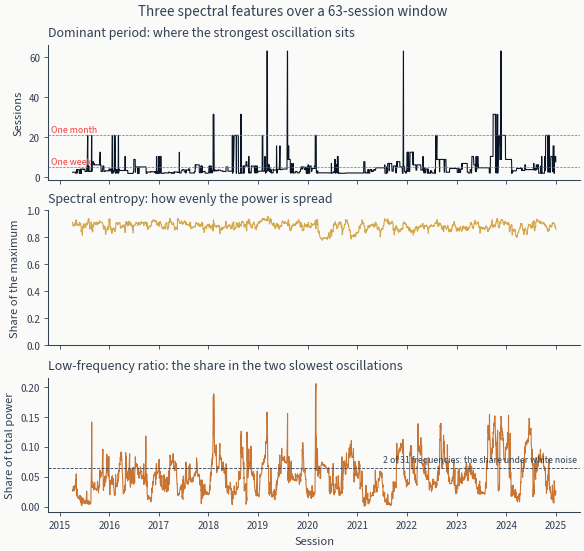

In [14]:
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE["grid_3x2"], sharex=True)

ax = axes[0]
ax.plot(sessions[covered], fft_out["dominant_period"][covered], linewidth=0.8, color=COLORS["blue"])
for period, label in [(5, "One week"), (21, "One month")]:
    ax.axhline(period, color=COLORS["negative"], linestyle="--", linewidth=0.5)
    ax.annotate(
        label,
        xy=(0.005, period),
        xycoords=("axes fraction", "data"),
        xytext=(0, 2),
        textcoords="offset points",
        fontsize=7,
        color=COLORS["negative"],
    )
ax.set_ylabel("Sessions")
ax.set_title("Dominant period: where the strongest oscillation sits")

ax = axes[1]
ax.plot(
    sessions[covered], fft_out["spectral_entropy"][covered], linewidth=0.8, color=COLORS["amber"]
)
ax.set_ylim(0, 1)
ax.set_ylabel("Share of the maximum")
ax.set_title("Spectral entropy: how evenly the power is spread")

ax = axes[2]
ax.plot(
    sessions[covered], fft_out["low_freq_ratio"][covered], linewidth=0.8, color=COLORS["copper"]
)
SLOW_BINS = 2  # the band the low-frequency ratio reads, in frequency bins
white_noise_share = SLOW_BINS / (FFT_WINDOW // 2)
ax.axhline(white_noise_share, color=COLORS["neutral"], linestyle="--", linewidth=0.6)
ax.annotate(
    f"{SLOW_BINS} of {FFT_WINDOW // 2} frequencies: the share under white noise",
    xy=(0.995, white_noise_share),
    xycoords=("axes fraction", "data"),
    xytext=(0, 4),
    textcoords="offset points",
    ha="right",
    fontsize=7,
    color=COLORS["neutral"],
)
ax.set_ylabel("Share of total power")
ax.set_xlabel("Session")
ax.set_title("Low-frequency ratio: the share in the two slowest oscillations")

fig.suptitle(f"Three spectral features over a {FFT_WINDOW}-session window")
show_with_alt(
    fig,
    "Three stacked panels sharing a time axis. The top plots the dominant period in "
    "sessions, a spiky series that mostly sits at the short end near the weekly reference "
    "line with occasional jumps to much longer periods. The middle plots the normalised "
    "spectral entropy, a high and fairly flat series close to the top of its range. The "
    "bottom plots the low-frequency ratio against a dashed reference at the share white "
    "noise would put in the same band, oscillating around and mostly below it.",
)

All three panels say the same thing about daily index returns, from different directions.
The entropy sits near its maximum, which means power is spread almost evenly across
frequencies; the low-frequency ratio hovers around the share white noise would put in the
same two bins; and the dominant period jumps around because with a nearly flat spectrum
the largest bin is decided by noise. That is what a spectrum of a near-white series looks
like, and it is the honest reading: these features are informative about *departures*
from that state rather than carrying a periodic structure of their own.

## Energy at calendar periods

The alternative to asking where the peak is is asking how much power sits at periods you
care about in advance. `energy_period_*` returns the raw power in the three frequency
bins around a named period, which scales with the volatility of the window like any other
power. The figure divides each by the window's total, which is what makes the three
comparable to each other and independent of the volatility level; a model reading the raw
columns has to do the same division or it is reading volatility three times.

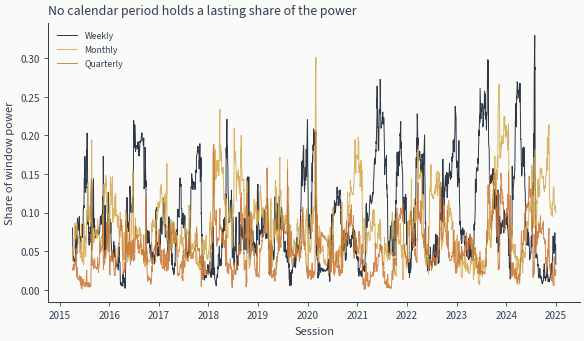

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for period, label, color in [
    (5, "Weekly", COLORS["blue"]),
    (21, "Monthly", COLORS["amber"]),
    (63, "Quarterly", COLORS["copper"]),
]:
    share = fft_out[f"energy_period_{period}"][covered] / fft_out["spectral_energy"][covered]
    ax.plot(sessions[covered], share, linewidth=0.7, color=color, label=label, alpha=0.85)
ax.set_ylabel("Share of window power")
ax.set_xlabel("Session")
ax.set_title("No calendar period holds a lasting share of the power")
ax.legend(fontsize=7)
show_with_alt(
    fig,
    "Three overlaid series showing the share of each window's power near the weekly, "
    "monthly and quarterly frequencies. All three oscillate in the same low range with no "
    "persistent separation and no trend over the decade; the weekly share reaches the "
    "highest individual peaks and the quarterly share the lowest.",
)

# Part 3: a steadier estimate of the same thing

A single Fourier transform of one window is a noisy estimate of the spectrum: its
variance does not fall as the window gets longer, because a longer window buys more
frequencies rather than a better estimate of each. **Welch's method** trades resolution
for stability by cutting the series into overlapping segments, transforming each, and
averaging. Fewer frequencies, each of them estimated better.

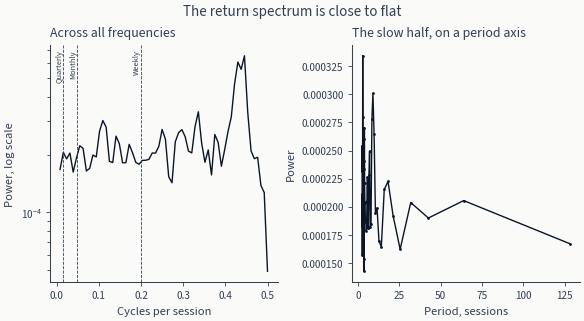

In [16]:
WELCH_SEGMENT = 128  # sessions per segment
WELCH_OVERLAP = 64  # sessions shared between consecutive segments

welch_freqs, welch_psd = welch(returns, fs=1.0, nperseg=WELCH_SEGMENT, noverlap=WELCH_OVERLAP)
welch_periods = np.where(welch_freqs > 0, 1.0 / np.maximum(welch_freqs, 1e-12), np.inf)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])

ax = axes[0]
ax.semilogy(welch_freqs[1:], welch_psd[1:], linewidth=1, color=COLORS["blue"])
for frequency, label in [(1 / 5, "Weekly"), (1 / 21, "Monthly"), (1 / 63, "Quarterly")]:
    ax.axvline(frequency, color=COLORS["neutral"], linestyle="--", linewidth=0.6)
    ax.annotate(
        label,
        xy=(frequency, 0.98),
        xycoords=("data", "axes fraction"),
        rotation=90,
        fontsize=6,
        va="top",
        ha="right",
        color=COLORS["neutral"],
    )
ax.set_xlabel("Cycles per session")
ax.set_ylabel("Power, log scale")
ax.set_title("Across all frequencies")

ax = axes[1]
slow_half = slice(1, 50)
ax.plot(
    welch_periods[slow_half],
    welch_psd[slow_half],
    linewidth=1,
    marker="o",
    markersize=2,
    color=COLORS["blue"],
)
ax.set_xlabel("Period, sessions")
ax.set_ylabel("Power")
ax.set_title("The slow half, on a period axis")

fig.suptitle("The return spectrum is close to flat")
show_with_alt(
    fig,
    "Two panels of the same Welch estimate. The left plots power against frequency on a "
    "log vertical axis with dashed markers at the weekly, monthly and quarterly "
    "frequencies; the curve is close to horizontal across the whole range with no peak at "
    "any marker. The right plots the slow half against period in sessions and shows the "
    "same near-flat level with scattered small fluctuations.",
)

A flat spectrum is the spectrum of white noise, and that is very nearly what daily index
returns have. No calendar frequency stands out, which is a result rather than a failure:
a tradable weekly cycle in a liquid index would be arbitraged away, and finding one here
would be a reason to suspect the calculation. What does vary is the *level* of the whole
curve over time, which is volatility, and that is what the next figure shows.

## Frequency against time

Running the same estimate on a moving window and stacking the results gives a picture
with time along one axis and period along the other, shaded by how much power sits at
each combination. A vertical band means a period when everything moved more; a horizontal
band would mean a period length that was persistently strong, and there are none.

In [17]:
PSD_WINDOW = 252  # sessions per estimate: about one year
PSD_STEP = 5  # sessions between estimates: one week
PSD_SEGMENT = 64  # sessions per segment inside each estimate; also the slowest period it resolves


def rolling_welch_psd(signal: np.ndarray, window: int, step: int, segment: int):
    """Welch estimates over successive windows; returns their end indices, frequencies, power."""
    ends, estimates, frequencies = [], [], None
    for end in range(window, len(signal), step):
        freqs, power = welch(
            signal[end - window : end],
            fs=1.0,
            nperseg=min(segment, window // 2),
            noverlap=segment // 2,
        )
        frequencies = freqs if frequencies is None else frequencies
        ends.append(end)
        estimates.append(power)
    return np.array(ends), frequencies, np.array(estimates)


psd_ends, psd_freqs, psd_matrix = rolling_welch_psd(returns, PSD_WINDOW, PSD_STEP, PSD_SEGMENT)

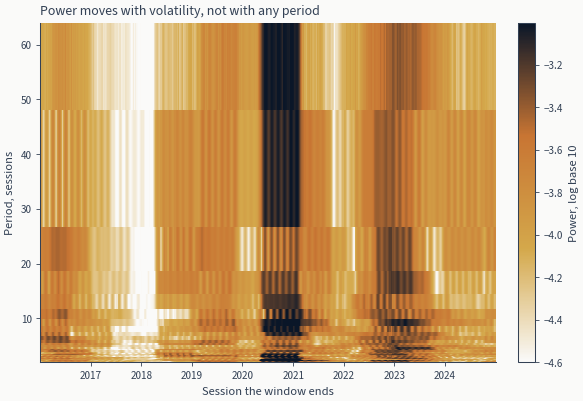

In [18]:
drawn = psd_freqs > 0
periods = 1.0 / psd_freqs[drawn]
power = np.log10(psd_matrix[:, drawn].T)

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
# The colour range spans the middle of the data rather than its extremes, so the shading
# is not compressed by a handful of cells.
mesh = ax.pcolormesh(
    sessions[psd_ends],
    periods,
    power,
    cmap=SPECTRUM_CMAP,
    shading="auto",
    vmin=np.percentile(power, 2),
    vmax=np.percentile(power, 98),
)
ax.set_ylim(periods.min(), periods.max())
ax.set_ylabel("Period, sessions")
ax.set_xlabel("Session the window ends")
ax.set_title("Power moves with volatility, not with any period")
fig.colorbar(mesh, ax=ax, label="Power, log base 10")
show_with_alt(
    fig,
    "A heat map with time across the bottom and oscillation period up the side, shaded "
    "from pale for low power to dark for high. The shading is close to uniform vertically "
    "at any given time, so no period stands out. It darkens across the whole height for a "
    "wide band running from mid-2020 into 2021, and again more faintly around 2023.",
)

Two things about reading this picture. The dark band arrives after the event that caused
it and outlasts it: each column is an estimate over the year *ending* at that session, so
a volatile month darkens every window that still contains it, for a year afterwards. And
the slowest period drawn is set by the segment length inside each estimate rather than by
the window: averaging over 64-session segments is what buys the stability, and it is also
what makes 64 sessions the slowest oscillation any of these estimates can see.

# Part 4: the feature table

The same three columns at three window lengths. A short window resolves few frequencies
and updates quickly; a long one resolves many and responds slowly. Keeping all three lets
a model use whichever timescale carries the information rather than committing in advance.

In [19]:
FEATURE_WINDOWS = [21, 63, 126]

feature_columns = {"timestamp": sessions}
for window in FEATURE_WINDOWS:
    computed = rolling_fft_features(returns, window, TARGET_PERIODS)
    for name in ["spectral_entropy", "low_freq_ratio", "dominant_period"]:
        feature_columns[f"{name}_{window}d"] = computed[name]

# Polars keeps NaN and null distinct and `drop_nulls` drops only the second, so the
# warm-up rows are converted before being dropped.
feature_df = (
    pl.DataFrame(feature_columns).with_columns(pl.exclude("timestamp").fill_nan(None)).drop_nulls()
)
print(f"Feature table: {feature_df.height:,} rows, {feature_df.width - 1} feature columns")
display(feature_df.tail(5))

Feature table: 2,389 rows, 9 feature columns


timestamp,spectral_entropy_21d,low_freq_ratio_21d,dominant_period_21d,spectral_entropy_63d,low_freq_ratio_63d,dominant_period_63d,spectral_entropy_126d,low_freq_ratio_126d,dominant_period_126d
datetime[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-12-24 00:00:00,0.912391,0.163372,3.5,0.892152,0.024903,10.5,0.904859,0.008957,2.210526
2024-12-26 00:00:00,0.913601,0.205053,7.0,0.877327,0.018775,10.5,0.900931,0.007401,10.5
2024-12-27 00:00:00,0.923401,0.177521,7.0,0.882324,0.019208,10.5,0.901726,0.007612,10.5
2024-12-30 00:00:00,0.828373,0.086217,7.0,0.870419,0.020156,10.5,0.901797,0.008738,10.5
2024-12-31 00:00:00,0.791448,0.07505,7.0,0.860737,0.026137,7.875,0.896023,0.012126,2.210526


## What they are worth

The **information coefficient** here is the Pearson correlation between a feature and the
return over the following five sessions. Two cautions before reading it. The forward
windows overlap, so consecutive rows are not independent and no significance follows from
the sample size. And a correlation computed once over a decade says nothing about whether
the relation held throughout it.

In [20]:
FORWARD_SESSIONS = 5

forward = np.full(len(prices), np.nan)
forward[:-FORWARD_SESSIONS] = (prices[FORWARD_SESSIONS:] - prices[:-FORWARD_SESSIONS]) / prices[
    :-FORWARD_SESSIONS
]

scored = feature_df.join(
    pl.DataFrame({"timestamp": sessions, "forward_return": forward}).with_columns(
        pl.col("forward_return").fill_nan(None)
    ),
    on="timestamp",
    how="inner",
).drop_nulls()
forward_values = scored["forward_return"].to_numpy()

ic_df = pd.DataFrame(
    [
        {
            "feature": column,
            "information coefficient": np.corrcoef(scored[column].to_numpy(), forward_values)[0, 1],
            "sessions": scored.height,
        }
        for column in scored.columns
        if column not in ("timestamp", "forward_return")
    ]
).sort_values("information coefficient", key=abs, ascending=False)
display(ic_df)

,feature,information coefficient,sessions
6,spectral_entropy_126d,-0.124199,2384
0,spectral_entropy_21d,-0.094840,2384
3,spectral_entropy_63d,-0.078574,2384
8,dominant_period_126d,-0.060758,2384
7,low_freq_ratio_126d,0.039800,2384
2,dominant_period_21d,-0.038826,2384
1,low_freq_ratio_21d,-0.012757,2384
5,dominant_period_63d,0.006430,2384
4,low_freq_ratio_63d,-0.004678,2384


## The features this notebook produces

| Column | What it measures | Causal |
|---|---|---|
| `spectral_entropy` | how evenly power is spread across frequencies, scaled to its maximum | yes |
| `dominant_period` | the period of the strongest oscillation in the window | yes |
| `low_freq_ratio` | the share of power in the two slowest oscillations the window resolves | yes |
| `energy_period_*` | the raw power in the bins around a named calendar period | yes |
| wavelet components | the series split by time scale | **no**, the transform reads the whole series |

`spectral_energy` is deliberately absent. It is the window variance rescaled, and a
rolling variance is the direct way to compute it.

## The library's spectral helpers

`ml4t.engineer` supplies two related expressions, and they answer different questions
from the ones above.

`rolling_entropy` bins the values in a window and computes the Shannon entropy of the
resulting histogram, in **bits**. It is an entropy of the distribution of returns, not of
their spectrum: the spectral entropy above asks how power is spread across frequencies,
this asks how the values are spread across a range. Its maximum is the base-two logarithm
of the bin count, which is what to read the printed mean against.

`fourier_features` is not a measurement of the series at all, and it is worth being clear
about this because the name suggests otherwise. It returns sine and cosine pairs of the
**row index**, at multiples of a base period the caller supplies. Nothing about the prices
enters them. They are a way of letting a linear model represent a smooth cycle of known
length, which is a legitimate and different job; the default base period is 390, the
number of trading minutes in a US session, so on daily data it must be given the period
that is meant.

In [21]:
ENTROPY_WINDOW = 50
ENTROPY_BINS = 10
SEASONAL_PERIOD = 252  # sessions in a year, the cycle the sine and cosine pairs describe
SEASONAL_COMPONENTS = 3

seasonal = fourier_features("close", n_components=SEASONAL_COMPONENTS, period=SEASONAL_PERIOD)
engineered = spy.with_columns(**seasonal).with_columns(
    return_entropy=rolling_entropy("returns", window=ENTROPY_WINDOW, n_bins=ENTROPY_BINS)
)

entropy_values = engineered["return_entropy"].drop_nulls()
print(f"Rolling entropy of returns: mean {entropy_values.mean():.3f} bits")
print(f"Maximum possible with {ENTROPY_BINS} bins: {np.log2(ENTROPY_BINS):.3f} bits")
print(f"Seasonal basis columns: {len(seasonal)} for {SEASONAL_COMPONENTS} harmonics")
display(
    engineered.select(["timestamp", "fourier_sin_1", "fourier_cos_1", "return_entropy"]).tail(3)
)

Rolling entropy of returns: mean 2.824 bits
Maximum possible with 10 bins: 3.322 bits
Seasonal basis columns: 6 for 3 harmonics


timestamp,fourier_sin_1,fourier_cos_1,return_entropy
date,f64,f64,f64
2024-12-27,-0.198146,0.980172,2.303923
2024-12-30,-0.173648,0.984808,2.348758
2024-12-31,-0.149042,0.988831,2.366105


The entropy sits close to its maximum, which is the distributional counterpart of the
flat spectrum: the returns in a fifty-session window spread across the bins about as
evenly as the binning allows. A window in which they concentrate would score lower, and
that is the departure the feature exists to catch.

## Key takeaways

1. **A wavelet decomposition is a research instrument.** It reads the whole series, so no
   component of it may be used as a feature. Its output is a decision about which time
   scales are worth computing rolling features at.
2. **The family matters less than the number of levels.** Three families give nearly the
   same slow component and differ only in the fastest detail, while the level count
   decides what each scale covers.
3. **Check what a derived feature reduces to.** Total spectral energy is the window
   variance times a constant, which a correlation of one and a fixed ratio establish, and
   a model given both is given one column twice.
4. **Scale a quantity that depends on the window length before comparing windows.**
   Spectral entropy grows with the number of frequencies in the window, so it is divided
   by its maximum here; the raw version ranks long windows above short ones for a reason
   that has nothing to do with the data.
5. **A flat spectrum is a finding.** Daily index returns have almost no periodic
   structure, so the spectral columns are informative about departures from that state
   rather than about a cycle. What does move is the level of the whole spectrum, which is
   volatility, and `08_garch_volatility` models it directly.

**Known limitations.** Every spectral quantity here assumes the window it reads comes
from one unchanging process, and a window containing a volatility break does not; the
estimate it returns is an average over two regimes. The information coefficients are
computed on overlapping forward windows over a single symbol and carry no significance.
And the wavelet scale-to-window mapping is a rule of thumb, checked here by correlation
rather than derived.

**Next**: `06_path_signatures` for features of the path rather than of its frequencies,
and `07_arima_features` for a model fitted in the time domain.